In [1]:
# KMeans implementation borrowed from my assignment submission of AI course
import numpy as np
import copy
import random
import matplotlib
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from PIL import Image
import os

In [2]:
class KMeansClustering:
    
    def __init__(self, filename: str, K:int):
        self.image_name = filename
        self.image = mpimg.imread(filename).copy()
        
        self.K = K
        self.centroids = None    
        self.sse_history = []
        self.all_centroids_history = []
        self.all_clusters_history = []
        self.temp_dir = "temp_frames"
        
        if not os.path.exists(self.temp_dir):
            os.makedirs(self.temp_dir)
    
    def __generate_initial_centroids(self) -> list:
        height, width, channel = self.image.shape
        indices = np.random.choice(height * width, size=self.K, replace=False)
        rows = indices // width
        cols = indices % width

        random_pixels = self.image[rows, cols]
        return random_pixels.tolist()
    
    def __calculate_distance(self, p1: tuple, p2: tuple) -> float:
        p1 = np.array(p1, dtype=np.float64)
        p2 = np.array(p2, dtype=np.float64)
        return np.sqrt(np.sum((p1 - p2)**2))

    def __assign_clusters(self) -> dict:
        clusters = {i: [] for i in range(self.K)}
        height, width, channels = self.image.shape 

        for i in range(height):
            for j in range(width):
                pixel = self.image[i, j]
                distances = [self.__calculate_distance(pixel, c) for c in self.centroids]
                cluster_idx = np.argmin(distances)
                clusters[cluster_idx].append((i, j))
        
        return clusters

    def __recompute_centroids(self) -> list:
        new_centroids = []
        
        for i in range(self.K):
            if len(self.clusters[i]) > 0: 
                pixels = np.array([self.image[r, c] for r, c in self.clusters[i]])
                new_centroid = pixels.mean(axis=0)
                new_centroids.append(new_centroid.tolist())
            else:
                new_centroids.append(self.centroids[i])
        
        return new_centroids

    def __create_iteration_visualization(self, iteration: int):
        vis_image = self.image.copy()
        height, width, _ = vis_image.shape
        
        temp_clusters = self.all_clusters_history[iteration]
        temp_centroids = self.all_centroids_history[iteration]
        
        for cluster_idx in range(self.K):
            centroid_color = np.array(temp_centroids[cluster_idx])
            for r, c in temp_clusters[cluster_idx]:
                vis_image[r, c] = centroid_color
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        
        ax1.imshow(self.image.astype(np.uint8))
        ax1.set_title('Original Image')
        ax1.axis('off')
        
        ax2.imshow(vis_image.astype(np.uint8))
        ax2.set_title(f'Iteration {iteration + 1}\nClusters: {self.K}, SSE: {self.sse_history[iteration]:.2f}')
        ax2.axis('off')
        
        plt.tight_layout()
        
        frame_path = os.path.join(self.temp_dir, f"frame_{iteration:03d}.png")
        plt.savefig(frame_path, dpi=100, bbox_inches='tight')
        plt.close()
        
        return frame_path

    def __create_gif(self, frame_paths: list, output_path: str, duration: int = 500):
        frames = []
        for path in frame_paths:
            frames.append(Image.open(path))
        
        frames[0].save(
            output_path,
            save_all=True,
            append_images=frames[1:],
            duration=duration,
            loop=0
        )
        
        print(f"GIF saved as: {output_path}")

    def __cleanup_temp_files(self, frame_paths: list):
        for path in frame_paths:
            try:
                os.remove(path)
            except OSError:
                pass
        try:
            os.rmdir(self.temp_dir)
        except OSError:
            pass

    def apply(self):
        self.centroids = self.__generate_initial_centroids()
        count = 0
        frame_paths = []
        
        while True:  
            count += 1
            print("Iteration #", count)

            self.all_centroids_history.append(copy.deepcopy(self.centroids))

            self.clusters = self.__assign_clusters()
            self.all_clusters_history.append(copy.deepcopy(self.clusters))

            self.sse_history.append(self.__compute_sse_value(self.clusters, self.centroids))

            frame_path = self.__create_iteration_visualization(len(self.all_centroids_history) - 1)
            frame_paths.append(frame_path)

            new_centroids = self.__recompute_centroids()
            old_centroids = self.centroids

            new_centroids_np = np.array(new_centroids)
            old_centroids_np = np.array(old_centroids)

            if np.round(np.sum(new_centroids_np - old_centroids_np), 2) == 0:
                break

            self.centroids = new_centroids

        for key in self.clusters:
            for r, c in self.clusters[key]:
                self.image[r, c] = self.centroids[key]

        gif_path = f"{self.image_name}_cluster_formation.gif"
        self.__create_gif(frame_paths, gif_path)
        
        self.__cleanup_temp_files(frame_paths)
        
        self.__save_image()

    def __compute_sse_value(self, clusters: dict, centroids: list) -> float:
        sse = 0
        for i in range(self.K):
            centroid = np.array(centroids[i])
            for r, c in clusters[i]:
                pixel = self.image[r, c]
                sse += np.sum((pixel - centroid)**2)
        print(f"SSE: {sse}")
        return sse
        
    def __save_image(self):
        mpimg.imsave(f"{self.image_name}_segmented_image.png", self.image)

    def show_result(self):
        plt.imshow(self.image.astype(np.uint8))
        plt.axis('off') 
        plt.show()

    def print_centroids(self):
        for idx, c in enumerate(self.centroids):
            print(f"Centroid {idx}: {c}")

    def quality(self):
        final_sse = self.__compute_sse_value(self.clusters, self.centroids)
        print(f"SSE (Sum of Squared Error) after convergence: {final_sse}")
        
        plt.figure(figsize=(8, 5))
        plt.plot(range(1, len(self.sse_history) + 1), self.sse_history, marker='o', linestyle='-', color='b')
        plt.title('SSE vs. K-Means Iteration')
        plt.xlabel('Iteration Number')
        plt.ylabel('Sum of Squared Error (SSE)')
        plt.grid(True)
        plt.show()


In [3]:
class FuzzyCMeansClustering:
    
    def __init__(self, filename: str, C: int, m: float = 2.0):
        self.image_name = filename
        self.image = mpimg.imread(filename).copy()
        
        self.C = C
        self.m = m # this is the degree of fuziness parameter
        self.centroids = None
        self.U = None           # membership matrix, shape (C x N). Has the degree for each cluster for each datapoint.
        self.objective_history = []
        self.all_centroids_history = []
        self.all_segmented_history = []
        self.segmented_image = None
        self.temp_dir = "temp_frames"
        
        if not os.path.exists(self.temp_dir):
            os.makedirs(self.temp_dir)
        
        # reshape image
        self.height, self.width, self.channels = self.image.shape
        self.N = self.height * self.width
        self.pixels = self.image.reshape(self.N, self.channels).astype(np.float64)
    
    def __initialize_membership(self):
        self.U = np.random.rand(self.C, self.N)
        col_sums = self.U.sum(axis=0, keepdims=True)
        self.U = self.U / col_sums # normalize between 0 and 1
    
    def __compute_centroids(self):
        um = self.U ** self.m                                   # (C x N)
        centroids = um.dot(self.pixels) / um.sum(axis=1, keepdims=True)  # (C x 3)
        return centroids
    
    def __compute_distances(self):
        dists = np.zeros((self.C, self.N))
        for i in range(self.C):
            diff = self.pixels - self.centroids[i]              # (N x 3)
            dists[i] = np.sqrt(np.sum(diff ** 2, axis=1))
        return dists
    
    def __update_membership(self, dists):
        dists = np.fmax(dists, np.finfo(np.float64).eps) # Prevents division by 0
        exponent = 2.0 / (self.m - 1)
        
        inv_dists = 1 / (dists ** (exponent))                        # (C x N)
        new_U = inv_dists / inv_dists.sum(axis=0, keepdims=True)
        return new_U
    
    def __compute_objective(self, dists):
        um = self.U ** self.m
        return np.sum(um * dists ** 2)
    
    def __get_segmented_image(self):
        labels = np.argmax(self.U, axis=0)                      # (N,)
        segmented = np.zeros_like(self.pixels)
        for i in range(self.C):
            mask = labels == i
            segmented[mask] = self.centroids[i]
        return segmented.reshape(self.height, self.width, self.channels).astype(np.uint8)
    
    def __create_iteration_visualization(self, iteration: int):
        segmented = self.all_segmented_history[iteration]
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        
        ax1.imshow(self.image.astype(np.uint8))
        ax1.set_title('Original Image')
        ax1.axis('off')
        
        ax2.imshow(segmented)
        ax2.set_title(f'Iteration {iteration + 1}\nC={self.C}, m={self.m}, J={self.objective_history[iteration]:.2f}')
        ax2.axis('off')
        
        plt.tight_layout()
        
        frame_path = os.path.join(self.temp_dir, f"fcm_frame_{iteration:03d}.png")
        plt.savefig(frame_path, dpi=100, bbox_inches='tight')
        plt.close()
        
        return frame_path
    
    def __create_gif(self, frame_paths: list, output_path: str, duration: int = 500):
        frames = []
        for path in frame_paths:
            frames.append(Image.open(path))
        
        frames[0].save(
            output_path,
            save_all=True,
            append_images=frames[1:],
            duration=duration,
            loop=0
        )
        
        print(f"GIF saved as: {output_path}")
    
    def __cleanup_temp_files(self, frame_paths: list):
        for path in frame_paths:
            try:
                os.remove(path)
            except OSError:
                pass
        try:
            os.rmdir(self.temp_dir)
        except OSError:
            pass
    
    def apply(self):
        self.__initialize_membership()
        count = 0
        frame_paths = []
        max_iter = 100
        tolerance = 1e-4
        
        while count < max_iter:
            count += 1
            print(f"Iteration # {count}")
            
            U_old = self.U.copy()
            
            self.centroids = self.__compute_centroids()
            self.all_centroids_history.append(self.centroids.copy())
            
            dists = self.__compute_distances()
            
            obj = self.__compute_objective(dists)
            self.objective_history.append(obj)
            print(f"Objective J: {obj:.2f}")
            
            segmented = self.__get_segmented_image()
            self.all_segmented_history.append(segmented)
            
            frame_path = self.__create_iteration_visualization(count - 1)
            frame_paths.append(frame_path)
            
            self.U = self.__update_membership(dists)
            
            change = np.linalg.norm(self.U - U_old)
            print(f"Membership change: {change:.6f}")
            if change < tolerance:
                print(f"Converged after {count} iterations.")
                break
            
        self.segmented_image = self.__get_segmented_image()
        
        gif_path = f"{self.image_name}_fcm_cluster_formation.gif"
        self.__create_gif(frame_paths, gif_path)
        self.__cleanup_temp_files(frame_paths)
        
        self.__save_image()
    
    def __save_image(self):
        mpimg.imsave(f"{self.image_name}_fcm_segmented.png", self.segmented_image)
    
    def show_result(self):
        plt.imshow(self.segmented_image)
        plt.axis('off')
        plt.show()
    
    def print_centroids(self):
        for idx, c in enumerate(self.centroids):
            print(f"Centroid {idx}: {c}")
    
    def quality(self):
        dists = self.__compute_distances()
        final_obj = self.__compute_objective(dists)
        print(f"Objective J after convergence: {final_obj:.2f}")
        
        plt.figure(figsize=(8, 5))
        plt.plot(range(1, len(self.objective_history) + 1), self.objective_history, marker='o', linestyle='-', color='b')
        plt.title('Objective Function (J) vs. FCM Iteration')
        plt.xlabel('Iteration Number')
        plt.ylabel('Objective Function (J)')
        plt.grid(True)
        plt.show()


Iteration # 1
SSE: 496407309
Iteration # 2
SSE: 388911054.8608349
Iteration # 3
SSE: 336345008.16869146
Iteration # 4
SSE: 312716945.60386866
Iteration # 5
SSE: 304694241.5673128
Iteration # 6
SSE: 301395079.1611566
Iteration # 7
SSE: 299771401.36177623
Iteration # 8
SSE: 298911749.456572
Iteration # 9
SSE: 297937548.32333094
Iteration # 10
SSE: 296563584.4734187
Iteration # 11
SSE: 295282821.14246416
Iteration # 12
SSE: 294132662.83064115
Iteration # 13
SSE: 292435256.14221585
Iteration # 14
SSE: 289115556.00636876
Iteration # 15
SSE: 278481593.4919453
Iteration # 16
SSE: 252392823.79368132
Iteration # 17
SSE: 242992079.1730442
Iteration # 18
SSE: 241198669.67783317
Iteration # 19
SSE: 240869000.62381452
Iteration # 20
SSE: 240766791.14863956
Iteration # 21
SSE: 240723335.43083996
Iteration # 22
SSE: 240705897.00641567
Iteration # 23
SSE: 240696813.34719244
Iteration # 24
SSE: 240693441.75732717
Iteration # 25
SSE: 240692473.34775528
Iteration # 26
SSE: 240692274.72613373
Iteration # 

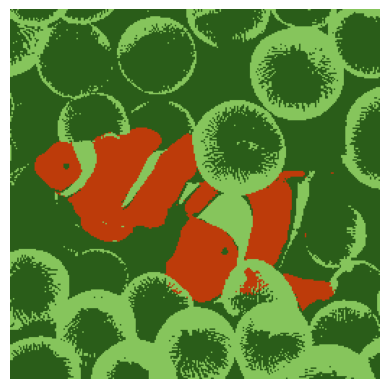

Centroid 0: [134.42149115734023, 197.74224587432136, 92.18464763747782]
Centroid 1: [42.693024742322955, 93.04674141742349, 25.442991450715105]
Centroid 2: [189.8213296398892, 59.92680588109951, 10.443532921372256]
SSE: 55911.95474461081
SSE (Sum of Squared Error) after convergence: 55911.95474461081


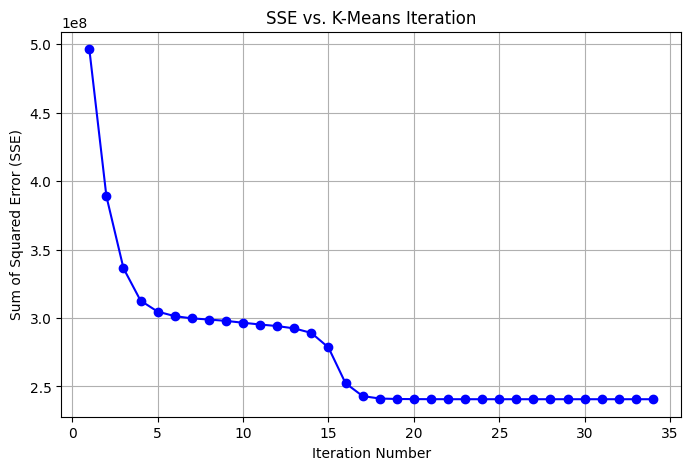

In [5]:
image_path = "images/sample1.jpg"
K = 3

kmeans = KMeansClustering(image_path, K)
kmeans.apply()
kmeans.show_result()
kmeans.print_centroids()
kmeans.quality()

Iteration # 1
Objective J: 299668647.08
Membership change: 79.988409
Iteration # 2
Objective J: 231580312.56
Membership change: 1.509579
Iteration # 3
Objective J: 231547977.12
Membership change: 3.318756
Iteration # 4
Objective J: 231382449.11
Membership change: 7.271815
Iteration # 5
Objective J: 230543318.90
Membership change: 14.966912
Iteration # 6
Objective J: 226682382.08
Membership change: 26.062161
Iteration # 7
Objective J: 214270012.00
Membership change: 31.399152
Iteration # 8
Objective J: 196749911.52
Membership change: 24.162181
Iteration # 9
Objective J: 188033688.63
Membership change: 21.431159
Iteration # 10
Objective J: 183883868.86
Membership change: 24.009073
Iteration # 11
Objective J: 179213695.70
Membership change: 20.948700
Iteration # 12
Objective J: 175431824.44
Membership change: 13.429934
Iteration # 13
Objective J: 173753997.32
Membership change: 8.446150
Iteration # 14
Objective J: 173053217.46
Membership change: 6.631783
Iteration # 15
Objective J: 172633

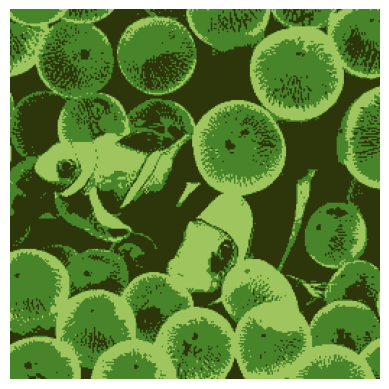

Centroid 0: [45.09754019 54.37953549 10.99870162]
Centroid 1: [159.96552769 198.49337331  94.05405899]
Centroid 2: [ 71.37789402 132.21786977  42.28199465]
Objective J after convergence: 171602065.81


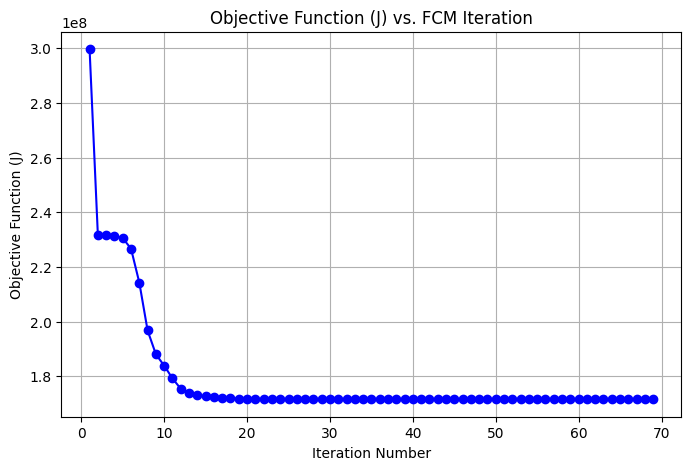

In [6]:
fcm = FuzzyCMeansClustering(image_path, C=K, m=2)
fcm.apply()
fcm.show_result()
fcm.print_centroids()
fcm.quality()

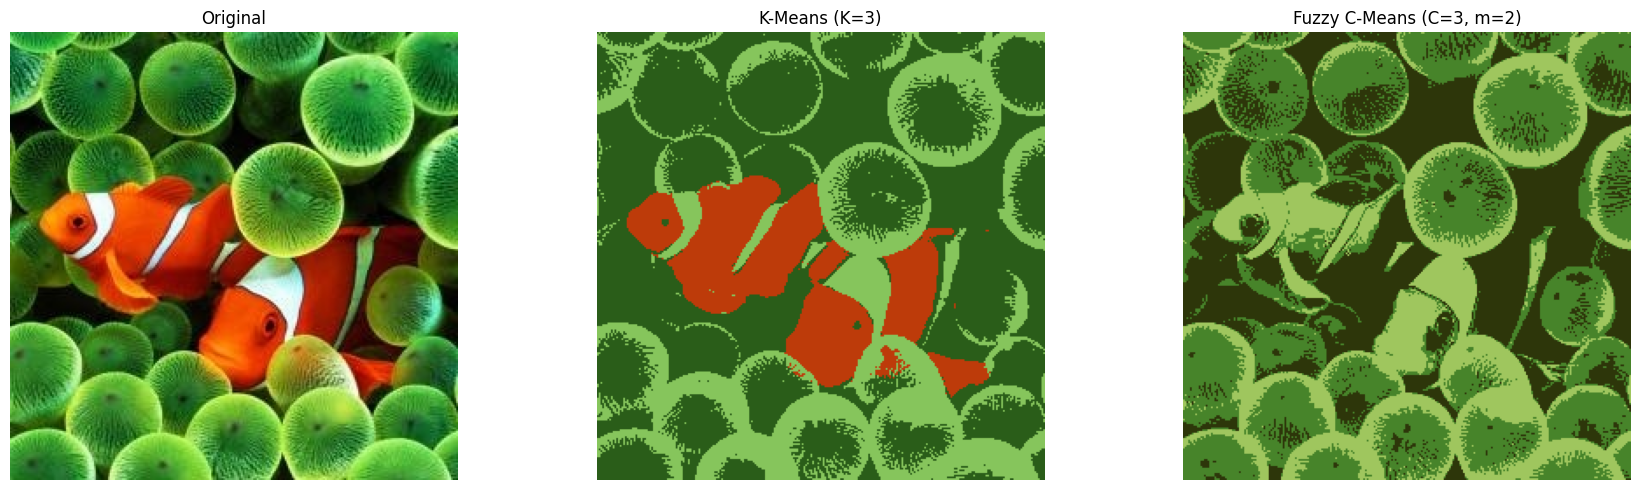

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
original = mpimg.imread(image_path)
axes[0].imshow(original)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(kmeans.image.astype(np.uint8))
axes[1].set_title(f"K-Means (K={K})")
axes[1].axis("off")

axes[2].imshow(fcm.segmented_image)
axes[2].set_title(f"Fuzzy C-Means (C={K}, m=2)")
axes[2].axis("off")

plt.tight_layout()
plt.show()